# Neural networks and Reservoir Computing


In [1]:
import sys

# Install dependencies if the notebook is running in Colab
if 'google.colab' in sys.modules:
    !pip install -U -qq reservoir_computing

In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import time
import plotly.graph_objects as go
import statsmodels.api as sm
from sklearn.datasets import make_circles
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from reservoir_computing.reservoir import Reservoir
from reservoir_computing.utils import make_forecasting_dataset
from reservoir_computing.datasets import PredLoader

## Упражнения

### Упражнение 1

- В примере MLP измените `window_size` ($P$) с 12 на 24.
- Прокомментируйте результаты и объясните, почему производительность улучшилась.

In [6]:
# Общая подготовка для упражнений
from itertools import product
from time import perf_counter
from IPython.display import display
import pandas as pd
from statsmodels.tsa.seasonal import STL
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings('ignore', category=ConvergenceWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

elec_full = PredLoader().get_data('ElecRome')
elec_hourly = np.mean(elec_full.reshape(-1, 6), axis=1)
elec_series = elec_hourly[:3000].astype(float)
elec_train_size = int(0.9 * len(elec_series))

print(f'Длина ряда электронагрузки: {len(elec_series)}')
print(f'Разбиение train/test: {elec_train_size}/{len(elec_series) - elec_train_size}')

Loaded ElecRome dataset.
Data shape:
  X: (137376, 1)
Длина ряда электронагрузки: 3000
Разбиение train/test: 2700/300


In [7]:
# Вспомогательные функции для MLP, ESN и базовых прогнозов

def run_mlp_forecast(series, window_size, forecast_horizon, hidden=(32, 16),
                     activation='relu', learning_rate_init=1e-3, max_iter=800):
    series = np.asarray(series, dtype=float).reshape(-1)
    train_size = int(0.9 * len(series))
    train, test = series[:train_size], series[train_size:]

    X_train, y_train_full = create_windows(train, window_size, forecast_horizon)
    X_test, y_test_full = create_windows(test, window_size, forecast_horizon)
    y_train = y_train_full[:, -1]
    y_test = y_test_full[:, -1]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = MLPRegressor(
        hidden_layer_sizes=hidden,
        activation=activation,
        solver='adam',
        learning_rate_init=learning_rate_init,
        max_iter=max_iter,
        random_state=RANDOM_STATE,
    )

    start = perf_counter()
    model.fit(X_train_scaled, y_train)
    train_time = perf_counter() - start

    start = perf_counter()
    pred = model.predict(X_test_scaled)
    test_time = perf_counter() - start

    target_indices = train_size + np.arange(
        window_size + forecast_horizon - 1,
        window_size + forecast_horizon - 1 + len(y_test),
    )

    return {
        'model': model,
        'mse': mean_squared_error(y_test, pred),
        'y_true': y_test,
        'pred': pred,
        'target_indices': target_indices,
        'X_test_raw': X_test,
        'train_time_s': train_time,
        'test_time_s': test_time,
        'window_size': window_size,
        'forecast_horizon': forecast_horizon,
        'hidden_layer_sizes': hidden,
        'activation': activation,
        'learning_rate_init': learning_rate_init,
    }


def run_esn_forecast(series, horizon, n_internal_units=400, spectral_radius=0.95,
                     input_scaling=0.2, connectivity=0.2, n_drop=10):
    series = np.asarray(series, dtype=float).reshape(-1, 1)
    n_test = int(np.ceil(0.1 * len(series)))
    train_end = len(series) - n_test

    Xtr, Ytr, Xte, Yte, data_scaler = make_forecasting_dataset(
        series, horizon=horizon, test_percent=0.1
    )

    start = perf_counter()
    reservoir = Reservoir(
        n_internal_units=n_internal_units,
        spectral_radius=spectral_radius,
        input_scaling=input_scaling,
        connectivity=connectivity,
    )
    states_tr = reservoir.get_states(Xtr[None, :, :], n_drop=n_drop, bidir=False)[0]
    ridge = Ridge(alpha=1.0)
    ridge.fit(states_tr, Ytr[n_drop:, 0])
    train_time = perf_counter() - start

    start = perf_counter()
    states_te = reservoir.get_states(Xte[None, :, :], n_drop=n_drop, bidir=False)[0]
    pred_scaled = ridge.predict(states_te)
    pred = data_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    test_time = perf_counter() - start

    y_true = Yte[n_drop:, 0]
    target_indices = train_end + horizon + n_drop + np.arange(len(y_true))

    return {
        'mse': mean_squared_error(y_true, pred),
        'y_true': y_true,
        'pred': pred,
        'target_indices': target_indices,
        'train_time_s': train_time,
        'test_time_s': test_time,
        'horizon': horizon,
        'n_internal_units': n_internal_units,
        'spectral_radius': spectral_radius,
        'input_scaling': input_scaling,
        'connectivity': connectivity,
    }


def valid_seasonal_naive_from_windows(result, period=24):
    horizon = result['forecast_horizon']
    window_size = result['window_size']
    steps_back = int(np.ceil(horizon / period) * period - horizon)
    source_index = window_size - 1 - steps_back

    if 0 <= source_index < window_size:
        baseline = result['X_test_raw'][:, source_index]
        label = f'seasonal naive, period={period}, source=t-{steps_back}'
    else:
        baseline = result['X_test_raw'][:, -1]
        label = 'persistence fallback'

    return mean_squared_error(result['y_true'], baseline), label


def result_row(method, result):
    return {
        'method': method,
        'mse': result['mse'],
        'train_time_s': result['train_time_s'],
        'test_time_s': result['test_time_s'],
    }

Loaded ElecRome dataset.
Data shape:
  X: (137376, 1)


,method,mse,train_time_s,test_time_s
0,MLP окно=12 горизонт=24,24.3760,3.5610,0.0005
1,MLP окно=24 горизонт=24,21.0839,3.6979,0.0004


Окно 24 меняет MSE на 13.51% относительно окна 12.


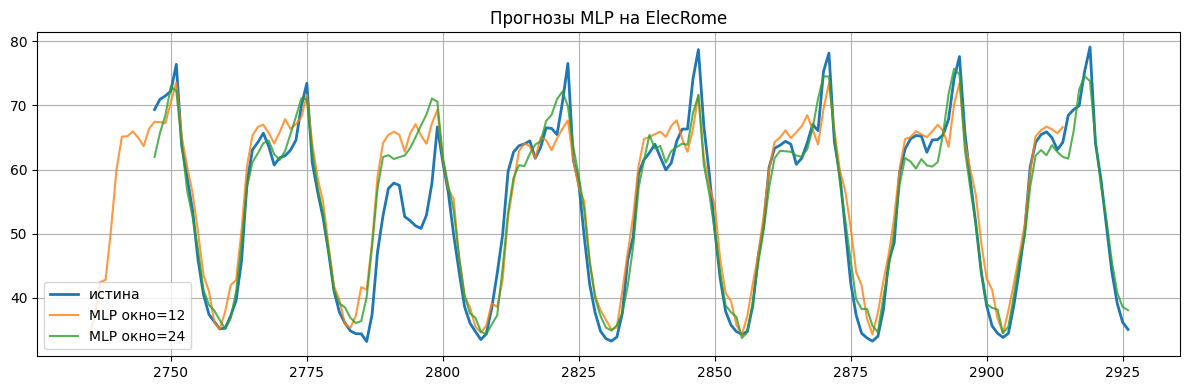

In [17]:
def create_windows(data, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size:i + window_size + forecast_horizon])
    return np.array(X), np.array(y)

ts_full = PredLoader().get_data('ElecRome')

# Resample the time series to hourly frequency
ts_hourly = np.mean(ts_full.reshape(-1, 6), axis=1)[:, None]

# Use only the first 3000 time steps
time_series = ts_hourly[0:3000, :]

# Split the time series into training and test sets
train_size = int(0.9*len(time_series))
tr = time_series[:train_size]
te = time_series[train_size:]

# Define window size and forecast horizon
window_size = 12
forecast_horizon = 12

# Create input-output pairs
X_train, y_train = create_windows(tr, window_size, forecast_horizon)
X_test, y_test = create_windows(te, window_size, forecast_horizon)

# MLP с window_size 12 и 24 при горизонте 24
mlp_w12_h24 = run_mlp_forecast(
    elec_series, window_size=12, forecast_horizon=24, hidden=(32, 16)
)
mlp_w24_h24 = run_mlp_forecast(
    elec_series, window_size=24, forecast_horizon=24, hidden=(32, 16)
)

exercise1 = pd.DataFrame([
    result_row('MLP окно=12 горизонт=24', mlp_w12_h24),
    result_row('MLP окно=24 горизонт=24', mlp_w24_h24),
])
display(exercise1.round(4))

improvement = 100 * (mlp_w12_h24['mse'] - mlp_w24_h24['mse']) / mlp_w12_h24['mse']
print(f'Окно 24 меняет MSE на {improvement:.2f}% относительно окна 12.')

plt.figure(figsize=(12, 4))
plt.plot(mlp_w24_h24['target_indices'][:180], mlp_w24_h24['y_true'][:180], label='истина', linewidth=2)
plt.plot(mlp_w12_h24['target_indices'][:180], mlp_w12_h24['pred'][:180], label='MLP окно=12', alpha=0.8)
plt.plot(mlp_w24_h24['target_indices'][:180], mlp_w24_h24['pred'][:180], label='MLP окно=24', alpha=0.8)
plt.title('Прогнозы MLP на ElecRome')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

Окно в 24 часа дает MLP полный суточный контекст, поэтому модель использует нагрузку в тот же час предыдущего дня, а не только половину суток истории.

### Упражнение 2
— В MLP измените «forecast_horizon» с 24 на 36.
- Сделайте то же самое и в ESN.
- С горизонтом прогноза размером 24 мы использовали в качестве бейзлайна MSE между временным рядом и его версией, смещенной на 24 лага, `mse =mean_squared_error(y_test[24:], y_test[:-24])`. Является ли это хорошей базой даже при изменении горизонта прогнозирования? Что может быть лучшим базлайном?

In [18]:
# forecast_horizon = 36 для MLP и ESN
mlp_w24_h36 = run_mlp_forecast(
    elec_series, window_size=24, forecast_horizon=36, hidden=(32, 16)
)
esn_h24 = run_esn_forecast(
    elec_series, horizon=24, n_internal_units=400,
    spectral_radius=0.95, input_scaling=0.2, connectivity=0.2,
)
esn_h36 = run_esn_forecast(
    elec_series, horizon=36, n_internal_units=400,
    spectral_radius=0.95, input_scaling=0.2, connectivity=0.2,
)

fixed_shift_mse = mean_squared_error(mlp_w24_h36['y_true'][24:], mlp_w24_h36['y_true'][:-24])
persistence_mse = mean_squared_error(mlp_w24_h36['y_true'], mlp_w24_h36['X_test_raw'][:, -1])
seasonal_mse, seasonal_label = valid_seasonal_naive_from_windows(mlp_w24_h36, period=24)

exercise2_models = pd.DataFrame([
    result_row('MLP окно=24 горизонт=36', mlp_w24_h36),
    result_row('ESN горизонт=24', esn_h24),
    result_row('ESN горизонт=36', esn_h36),
])
exercise2_baselines = pd.DataFrame([
    {'baseline': 'старый y_test со сдвигом 24', 'mse': fixed_shift_mse},
    {'baseline': 'персистентный y(t+h)=y(t)', 'mse': persistence_mse},
    {'baseline': seasonal_label, 'mse': seasonal_mse},
])

display(exercise2_models.round(4))
display(exercise2_baselines.round(4))


,method,mse,train_time_s,test_time_s
0,MLP окно=24 горизонт=36,34.2003,12.0089,0.0006
1,ESN горизонт=24,24.4477,1.9839,0.1803
2,ESN горизонт=36,37.4116,2.7588,0.0352


,baseline,mse
0,старый y_test со сдвигом 24,28.9381
1,персистентный y(t+h)=y(t),570.7589
2,"seasonal naive, period=24, source=t-12",31.7867


Старый фиксированный сдвиг на 24 шага привязан к горизонту 24 часа и не является универсальным baseline. <br>При смене горизонта baseline нужно считать от точки прогноза, например персистентный или корректный сезонный naive.

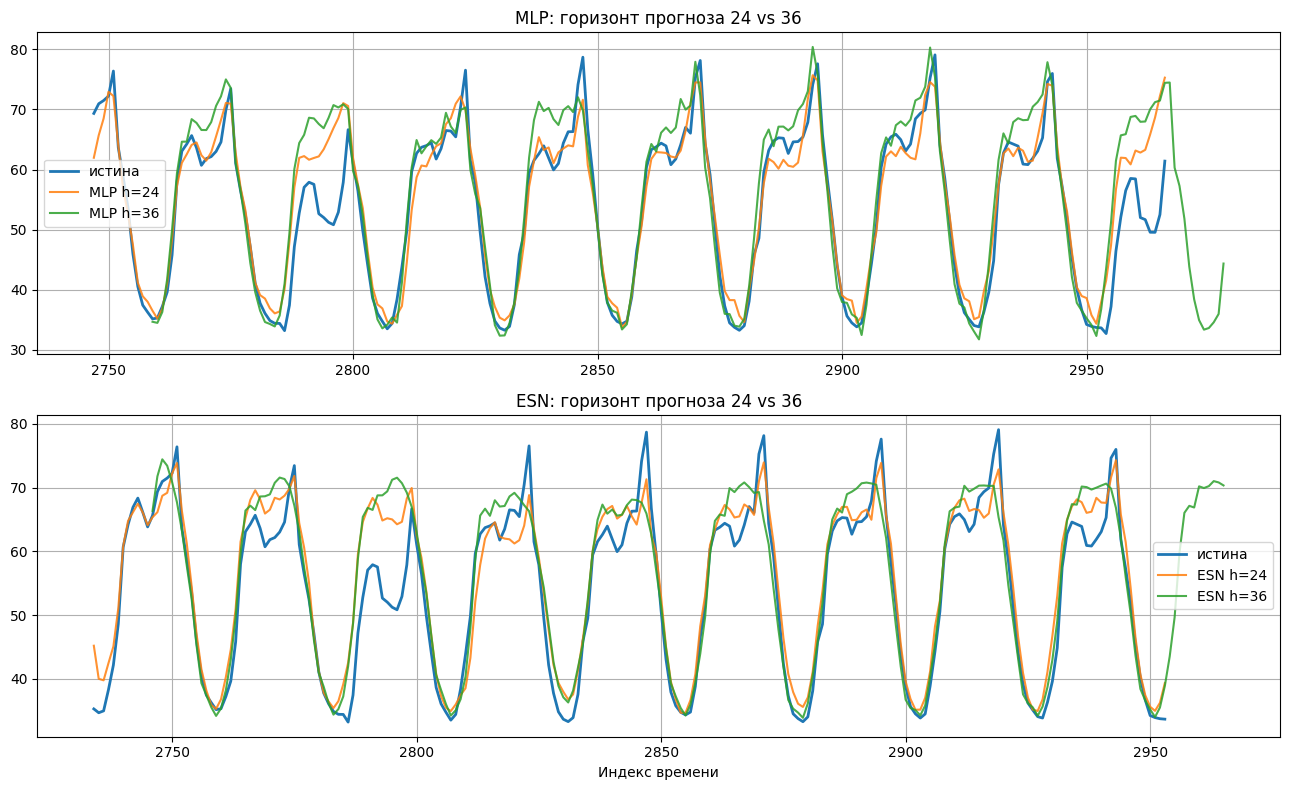

In [19]:
# Визуальное сравнение при смене горизонта и чувствительности ESN
n_plot = 220
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

axes[0].plot(mlp_w24_h24['target_indices'][:n_plot], mlp_w24_h24['y_true'][:n_plot], label='истина', linewidth=2)
axes[0].plot(mlp_w24_h24['target_indices'][:n_plot], mlp_w24_h24['pred'][:n_plot], label='MLP h=24', alpha=0.85)
axes[0].plot(mlp_w24_h36['target_indices'][:n_plot], mlp_w24_h36['pred'][:n_plot], label='MLP h=36', alpha=0.85)
axes[0].set_title('MLP: горизонт прогноза 24 vs 36')
axes[0].grid()
axes[0].legend()

n_plot_esn = min(len(esn_h24['y_true']), len(esn_h36['y_true']), 220)
axes[1].plot(esn_h24['target_indices'][:n_plot_esn], esn_h24['y_true'][:n_plot_esn], label='истина', linewidth=2)
axes[1].plot(esn_h24['target_indices'][:n_plot_esn], esn_h24['pred'][:n_plot_esn], label='ESN h=24', alpha=0.85)
axes[1].plot(esn_h36['target_indices'][:n_plot_esn], esn_h36['pred'][:n_plot_esn], label='ESN h=36', alpha=0.85)
axes[1].set_title('ESN: горизонт прогноза 24 vs 36')
axes[1].set_xlabel('Индекс времени')
axes[1].grid()
axes[1].legend()

plt.tight_layout()
plt.show()

### Упражнение 3

В отличие от подхода, основанного на моделях, такого как ARIMA, MLP и ESN строго не требуют, чтобы данные были стационарными. Однако, устранив тренд и сезонность, MLP и ESN могут сосредоточиться только на прогнозировании остатков.

- Удалите тренд и сезонность и обучите MLP и ESN обучению остатков.
- При тестировании не забывайте учитывать тенденцию и сезонность при расчете прогнозов.
- Сравните результаты с результатами, полученными при обучении MLP и ESN на исходных данных.

,model,mse
0,MLP исходный ряд,21.0839
1,MLP остатки + компоненты,9.3603
2,ESN исходный ряд,24.4477
3,ESN остатки + компоненты,11.4614


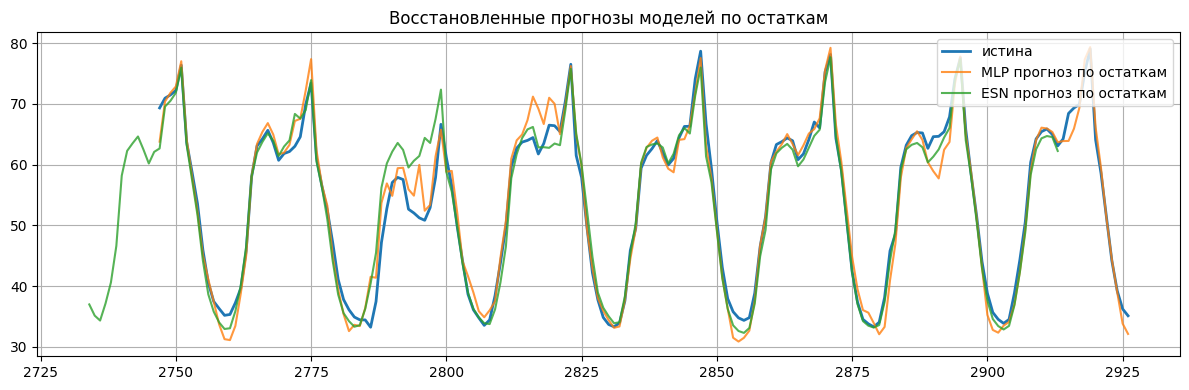

In [21]:
# Обучение MLP и ESN на остатках после удаления тренда/сезонности
stl = STL(elec_series, period=24, robust=True).fit()
component = np.asarray(stl.trend) + np.asarray(stl.seasonal)
elec_residuals = np.asarray(stl.resid)

mlp_resid = run_mlp_forecast(
    elec_residuals, window_size=24, forecast_horizon=24, hidden=(32, 16)
)
mlp_resid_pred_full = mlp_resid['pred'] + component[mlp_resid['target_indices']]
mlp_resid_true_full = elec_series[mlp_resid['target_indices']]
mlp_resid_mse_full = mean_squared_error(mlp_resid_true_full, mlp_resid_pred_full)

esn_resid = run_esn_forecast(
    elec_residuals, horizon=24, n_internal_units=400,
    spectral_radius=0.95, input_scaling=0.2, connectivity=0.2,
)
esn_resid_pred_full = esn_resid['pred'] + component[esn_resid['target_indices']]
esn_resid_true_full = elec_series[esn_resid['target_indices']]
esn_resid_mse_full = mean_squared_error(esn_resid_true_full, esn_resid_pred_full)

exercise3 = pd.DataFrame([
    {'model': 'MLP исходный ряд', 'mse': mlp_w24_h24['mse']},
    {'model': 'MLP остатки + компоненты', 'mse': mlp_resid_mse_full},
    {'model': 'ESN исходный ряд', 'mse': esn_h24['mse']},
    {'model': 'ESN остатки + компоненты', 'mse': esn_resid_mse_full},
])
display(exercise3.round(4))

plt.figure(figsize=(12, 4))
plt.plot(mlp_resid['target_indices'][:180], mlp_resid_true_full[:180], label='истина', linewidth=2)
plt.plot(mlp_resid['target_indices'][:180], mlp_resid_pred_full[:180], label='MLP прогноз по остаткам', alpha=0.8)
plt.plot(esn_resid['target_indices'][:180], esn_resid_pred_full[:180], label='ESN прогноз по остаткам', alpha=0.8)
plt.title('Восстановленные прогнозы моделей по остаткам')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

Обучение на остатках убирает доминирующую суточную компоненту до обучения.<br>Финальный прогноз получаем, возвращая тренд и сезонность в каждый момент цели.

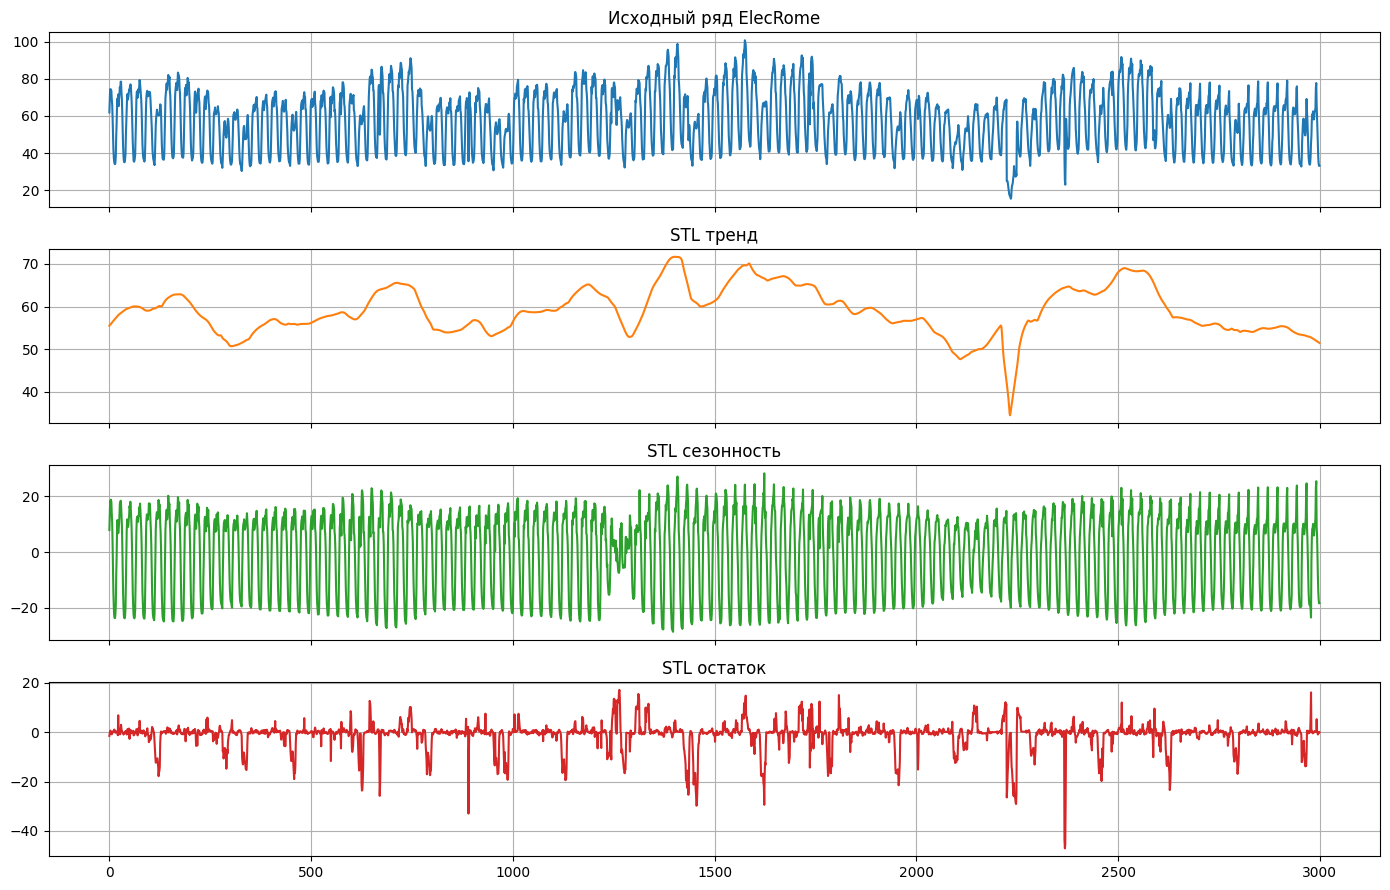

,model,mse,rmse,mae,r2,delta_mse_к_MLP_исходный_%
0,MLP исходный,21.0839,4.5917,3.1236,0.8778,0.0000
1,MLP остатки + обратное преобразование,9.3603,3.0595,2.0678,0.9457,-55.6044
2,ESN исходный,24.4477,4.9445,3.6655,0.8587,15.9545
3,ESN остатки + обратное преобразование,11.4614,3.3855,2.2189,0.9338,-45.6391


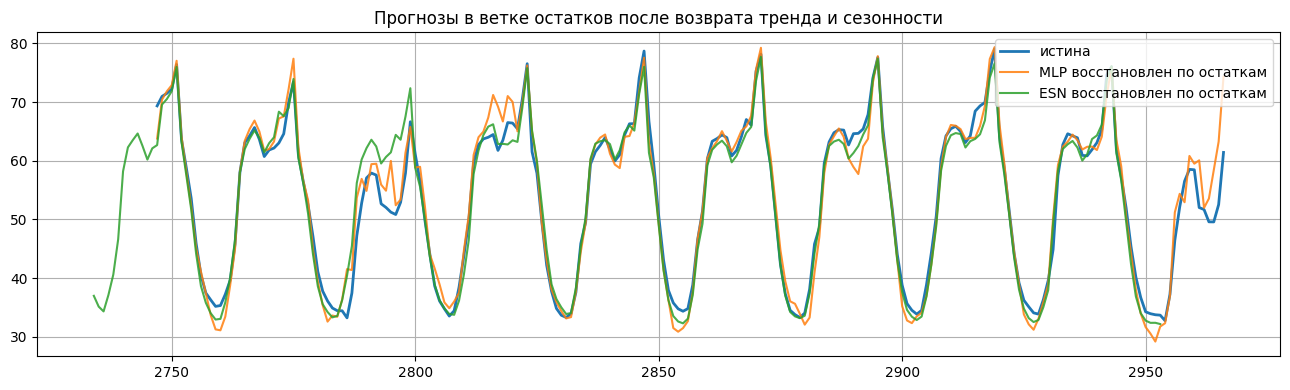

In [22]:
# Диагностика декомпозиции и детальное сравнение качества
from sklearn.metrics import mean_absolute_error, r2_score

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
axes[0].plot(elec_series, color='tab:blue')
axes[0].set_title('Исходный ряд ElecRome')
axes[0].grid()

axes[1].plot(stl.trend, color='tab:orange')
axes[1].set_title('STL тренд')
axes[1].grid()

axes[2].plot(stl.seasonal, color='tab:green')
axes[2].set_title('STL сезонность')
axes[2].grid()

axes[3].plot(stl.resid, color='tab:red')
axes[3].set_title('STL остаток')
axes[3].grid()

plt.tight_layout()
plt.show()

def metrics_frame(y_true, y_pred, model_name):
    return {
        'model': model_name,
        'mse': mean_squared_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
    }

quality_table = pd.DataFrame([
    metrics_frame(mlp_w24_h24['y_true'], mlp_w24_h24['pred'], 'MLP исходный'),
    metrics_frame(mlp_resid_true_full, mlp_resid_pred_full, 'MLP остатки + обратное преобразование'),
    metrics_frame(esn_h24['y_true'], esn_h24['pred'], 'ESN исходный'),
    metrics_frame(esn_resid_true_full, esn_resid_pred_full, 'ESN остатки + обратное преобразование'),
])

quality_table['delta_mse_к_MLP_исходный_%'] = 100 * (quality_table['mse'] - mlp_w24_h24['mse']) / mlp_w24_h24['mse']
display(quality_table.round(4))

plt.figure(figsize=(13, 4))
ix = slice(0, 220)
plt.plot(mlp_resid['target_indices'][ix], mlp_resid_true_full[ix], label='истина', linewidth=2)
plt.plot(mlp_resid['target_indices'][ix], mlp_resid_pred_full[ix], label='MLP восстановлен по остаткам', alpha=0.85)
plt.plot(esn_resid['target_indices'][ix], esn_resid_pred_full[ix], label='ESN восстановлен по остаткам', alpha=0.85)
plt.title('Прогнозы в ветке остатков после возврата тренда и сезонности')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Упражнение 4

В этом упражнении мы рассмотрим новый набор данных, состоящий из почасовых значений температуры воды в Мексиканском заливе недалеко от Ки-Уэста, Флорида.
Почасовые температуры указаны с 3 октября 2016 г. по 3 октября 2017 г.
Набор данных состоит из кадра данных с 6572 наблюдениями по следующим трем переменным.

- `DateTime` Дата и время чтения (формат мм/дд/гггг ч:м).
- «WaterTemp»: температура воды (в градусах Фаренгейта).
- `t`: индекс времени (от 1 до 673).

Raw data:
------------------
          DateTime  WaterTemp  t
0  10/3/2016 0:00       86.2  1
1  10/3/2016 1:00       86.2  2
2  10/3/2016 2:00       86.2  3
3  10/3/2016 3:00       86.2  4
4  10/3/2016 4:00       86.0  5


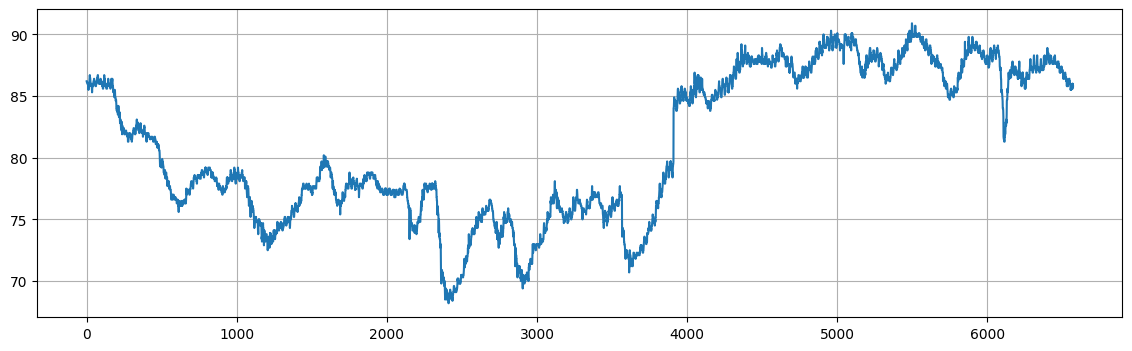

In [23]:
temps = sm.datasets.get_rdataset("KeyWestWater", "Stat2Data").data
print("Raw data:\n------------------\n", temps.head())
plt.figure(figsize=(14,4))
plt.plot(temps["WaterTemp"])
plt.grid()
plt.show()

- Примените MLP к данным температуры.
- Выполните поиск по небольшой сетке, чтобы попробовать разные значения для следующих гиперпараметров:
- `hidden_layer_sizes` (например, попробуйте больше слоев `[16, 16, 8]`, слоев с большим количеством блоков `[32, 16]` и т. д.).
- `learning_rate_init`.
- «активация» (попробуйте хотя бы «tanh» и «relu»).
- Примените ESN к данным температуры.
- Выполните поиск по небольшой сетке, чтобы попробовать разные значения для следующих гиперпараметров:
- `спектральный_радиус`.
- `input_scaling`.
- `n_internal_units`.
- `связность`.

Сообщите о конфигурации MLP и ESN, которая обеспечивает наилучшую производительность на тестовых данных.

In [24]:
# MLP grid search для KeyWestWater
temp_series = temps['WaterTemp'].astype(float).to_numpy()

temp_mlp_grid = [
    {'hidden': (16, 8), 'activation': 'relu', 'learning_rate_init': 1e-3},
    {'hidden': (32, 16), 'activation': 'relu', 'learning_rate_init': 5e-4},
    {'hidden': (16, 16, 8), 'activation': 'tanh', 'learning_rate_init': 1e-3},
    {'hidden': (32, 16), 'activation': 'tanh', 'learning_rate_init': 5e-4},
]

mlp_temp_results = []
for params in temp_mlp_grid:
    res_mlp = run_mlp_forecast(
        temp_series,
        window_size=24,
        forecast_horizon=1,
        hidden=params['hidden'],
        activation=params['activation'],
        learning_rate_init=params['learning_rate_init'],
        max_iter=600,
    )
    mlp_temp_results.append({
        'hidden_layer_sizes': params['hidden'],
        'activation': params['activation'],
        'learning_rate_init': params['learning_rate_init'],
        'mse': res_mlp['mse'],
        'train_time_s': res_mlp['train_time_s'],
        'test_time_s': res_mlp['test_time_s'],
        'result': res_mlp,
    })

mlp_temp_table = pd.DataFrame(mlp_temp_results).drop(columns='result').sort_values('mse')
best_mlp_temp = min(mlp_temp_results, key=lambda row: row['mse'])
display(mlp_temp_table.round(5))
print(f"Лучший MLP: hidden={best_mlp_temp['hidden_layer_sizes']}, activation={best_mlp_temp['activation']}, lr={best_mlp_temp['learning_rate_init']}, MSE={best_mlp_temp['mse']:.5f}")

,hidden_layer_sizes,activation,learning_rate_init,mse,train_time_s,test_time_s
0,"(16, 8)",relu,0.0010,0.07484,7.05962,0.00258
1,"(32, 16)",relu,0.0005,0.11044,17.99416,0.00076
3,"(32, 16)",tanh,0.0005,0.15700,23.53737,0.00224
2,"(16, 16, 8)",tanh,0.0010,47.17144,19.35218,0.00237


Лучший MLP: hidden=(16, 8), activation=relu, lr=0.001, MSE=0.07484


In [25]:
# ESN grid search для KeyWestWater
temp_esn_grid = [
    {'spectral_radius': 0.80, 'input_scaling': 0.05, 'n_internal_units': 150, 'connectivity': 0.10},
    {'spectral_radius': 0.95, 'input_scaling': 0.10, 'n_internal_units': 250, 'connectivity': 0.20},
    {'spectral_radius': 0.99, 'input_scaling': 0.20, 'n_internal_units': 250, 'connectivity': 0.10},
    {'spectral_radius': 1.05, 'input_scaling': 0.20, 'n_internal_units': 350, 'connectivity': 0.25},
]

esn_temp_results = []
for params in temp_esn_grid:
    res_esn = run_esn_forecast(
        temp_series,
        horizon=1,
        n_internal_units=params['n_internal_units'],
        spectral_radius=params['spectral_radius'],
        input_scaling=params['input_scaling'],
        connectivity=params['connectivity'],
    )
    esn_temp_results.append({
        'spectral_radius': params['spectral_radius'],
        'input_scaling': params['input_scaling'],
        'n_internal_units': params['n_internal_units'],
        'connectivity': params['connectivity'],
        'mse': res_esn['mse'],
        'train_time_s': res_esn['train_time_s'],
        'test_time_s': res_esn['test_time_s'],
        'result': res_esn,
    })

esn_temp_table = pd.DataFrame(esn_temp_results).drop(columns='result').sort_values('mse')
best_esn_temp = min(esn_temp_results, key=lambda row: row['mse'])
display(esn_temp_table.round(5))
print(f"Лучший ESN: spectral_radius={best_esn_temp['spectral_radius']}, input_scaling={best_esn_temp['input_scaling']}, units={best_esn_temp['n_internal_units']}, connectivity={best_esn_temp['connectivity']}, MSE={best_esn_temp['mse']:.5f}")

,spectral_radius,input_scaling,n_internal_units,connectivity,mse,train_time_s,test_time_s
2,0.99,0.20,250,0.10,0.04824,0.62886,0.08184
1,0.95,0.10,250,0.20,0.04968,0.91900,0.09117
3,1.05,0.20,350,0.25,0.04972,1.00796,0.06481
0,0.80,0.05,150,0.10,0.05132,0.51710,0.08159


Лучший ESN: spectral_radius=0.99, input_scaling=0.2, units=250, connectivity=0.1, MSE=0.04824


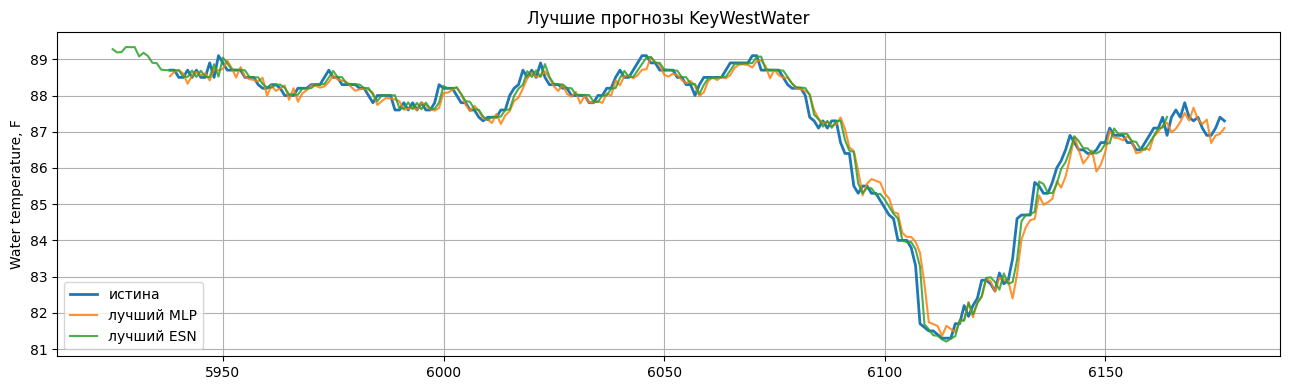

,model,лучшая_конфигурация,mse
0,MLP,"hidden=(16, 8), activation=relu, lr=0.001",0.07484
1,ESN,"sr=0.99, input=0.2, units=250, conn=0.1",0.04824


In [26]:
# Визуальное сравнение лучших прогнозов KeyWestWater
best_mlp_result = best_mlp_temp['result']
best_esn_result = best_esn_temp['result']

n_plot = 240
plt.figure(figsize=(13, 4))
plt.plot(best_mlp_result['target_indices'][:n_plot], best_mlp_result['y_true'][:n_plot], label='истина', linewidth=2)
plt.plot(best_mlp_result['target_indices'][:n_plot], best_mlp_result['pred'][:n_plot], label='лучший MLP', alpha=0.85)
plt.plot(best_esn_result['target_indices'][:n_plot], best_esn_result['pred'][:n_plot], label='лучший ESN', alpha=0.85)
plt.title('Лучшие прогнозы KeyWestWater')
plt.ylabel('Water temperature, F')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

best_config_summary = pd.DataFrame([
    {
        'model': 'MLP',
        'лучшая_конфигурация': f"hidden={best_mlp_temp['hidden_layer_sizes']}, activation={best_mlp_temp['activation']}, lr={best_mlp_temp['learning_rate_init']}",
        'mse': best_mlp_temp['mse'],
    },
    {
        'model': 'ESN',
        'лучшая_конфигурация': f"sr={best_esn_temp['spectral_radius']}, input={best_esn_temp['input_scaling']}, units={best_esn_temp['n_internal_units']}, conn={best_esn_temp['connectivity']}",
        'mse': best_esn_temp['mse'],
    },
])
display(best_config_summary.round(5))

,model,mse,mae
0,Лучший MLP,0.07484,0.19585
1,Лучший ESN,0.94029,0.64158


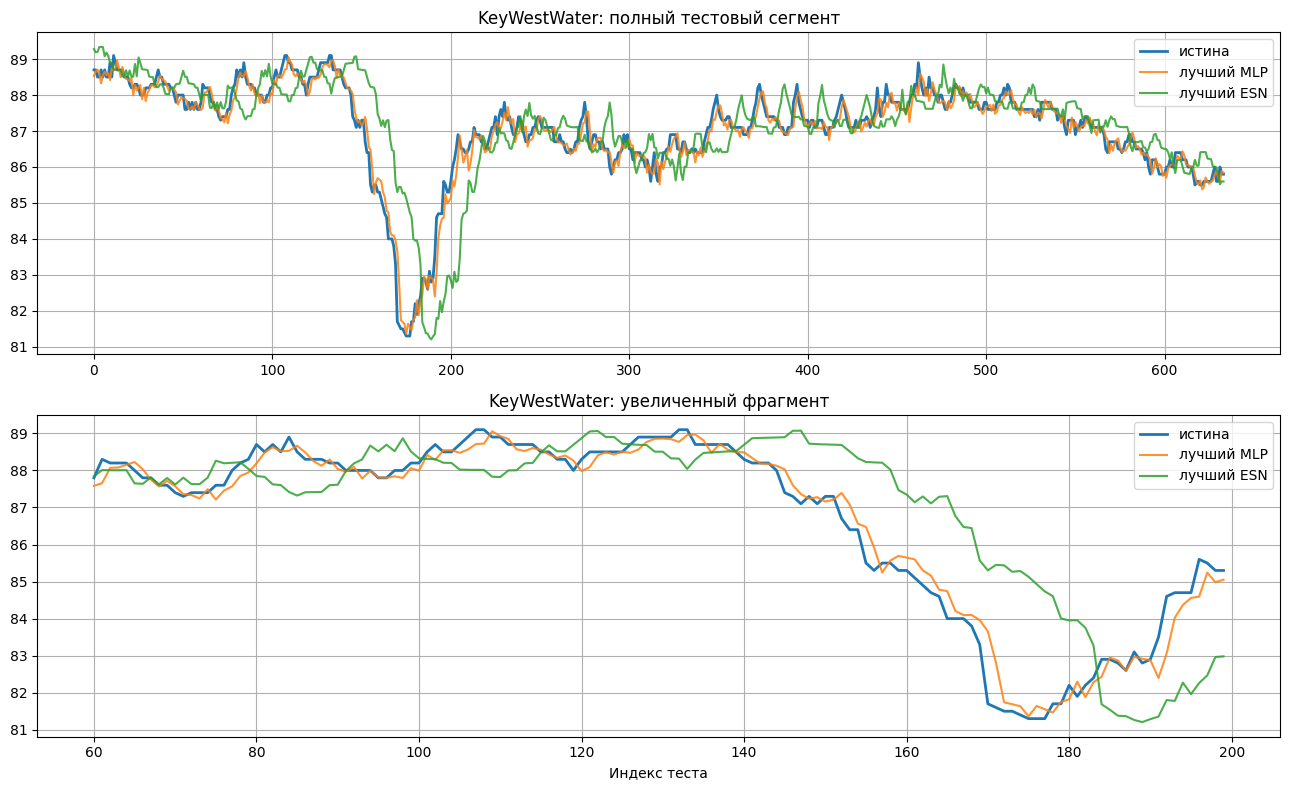

In [27]:
# Диагностика бок-о-бок (полный отрезок + увеличенный фрагмент)
from sklearn.metrics import mean_absolute_error

common_n = min(len(best_mlp_result['y_true']), len(best_esn_result['y_true']))
y_true_common = best_mlp_result['y_true'][:common_n]
y_mlp_common = best_mlp_result['pred'][:common_n]
y_esn_common = best_esn_result['pred'][:common_n]

diagnostics = pd.DataFrame([
    {'model': 'Лучший MLP', 'mse': mean_squared_error(y_true_common, y_mlp_common), 'mae': mean_absolute_error(y_true_common, y_mlp_common)},
    {'model': 'Лучший ESN', 'mse': mean_squared_error(y_true_common, y_esn_common), 'mae': mean_absolute_error(y_true_common, y_esn_common)},
]).sort_values('mse')

display(diagnostics.round(5))

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

axes[0].plot(y_true_common, label='истина', linewidth=2)
axes[0].plot(y_mlp_common, label='лучший MLP', alpha=0.85)
axes[0].plot(y_esn_common, label='лучший ESN', alpha=0.85)
axes[0].set_title('KeyWestWater: полный тестовый сегмент')
axes[0].grid()
axes[0].legend()

zoom_left, zoom_right = 60, 200
axes[1].plot(np.arange(zoom_left, zoom_right), y_true_common[zoom_left:zoom_right], label='истина', linewidth=2)
axes[1].plot(np.arange(zoom_left, zoom_right), y_mlp_common[zoom_left:zoom_right], label='лучший MLP', alpha=0.85)
axes[1].plot(np.arange(zoom_left, zoom_right), y_esn_common[zoom_left:zoom_right], label='лучший ESN', alpha=0.85)
axes[1].set_title('KeyWestWater: увеличенный фрагмент')
axes[1].set_xlabel('Индекс теста')
axes[1].grid()
axes[1].legend()

plt.tight_layout()
plt.show()